# ✉️ Email Spam Detection

This project builds machine learning models to classify email/SMS messages into **Spam** or **Ham** (legitimate).

## 📊 Dataset
The dataset contains 5572 messages with the following columns:
- `label`: Whether the message is `ham` or `spam`.
- `message`: The raw text content of the message.

In [1]:
import pandas as pd
import numpy as np
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set plot styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)

In [2]:
# Read CSV, ignoring encoding errors
df = pd.read_csv('dataset.csv', encoding='latin-1')

# Keep only relevant columns and rename
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'message'})

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


--- Class Distribution ---
label
ham     4825
spam     747
Name: count, dtype: int64


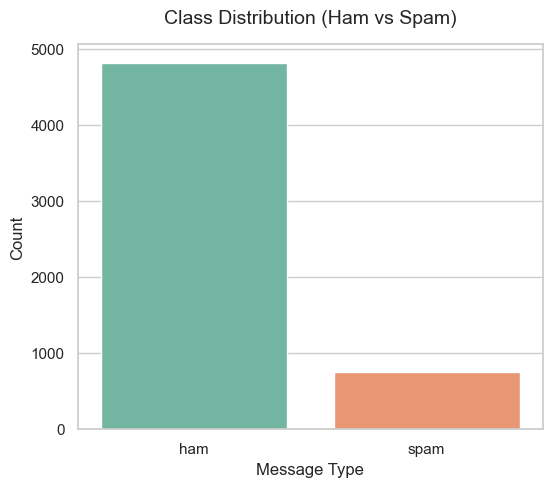

In [3]:
# Check class distribution
print("--- Class Distribution ---")
print(df['label'].value_counts())

# Plot distribution
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='label', palette='Set2', hue='label', legend=False)
plt.title("Class Distribution (Ham vs Spam)", fontsize=14, pad=15)
plt.xlabel("Message Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.savefig("spam_vs_not_spam.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])
    # Remove English stopwords
    text = ' '.join([word for word in text.split() if word not in ENGLISH_STOP_WORDS])
    return text

# Clean text messages
df['message_cleaned'] = df['message'].apply(clean_text)

# Map labels to numerical values (ham=0, spam=1)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,message,message_cleaned
0,0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,u dun say early hor u c say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives


In [5]:
X = df['message_cleaned']
y = df['label']

# Stratified train-test split (80/20) to maintain balanced class ratio
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train_raw.shape[0]}")
print(f"Testing set size: {X_test_raw.shape[0]}")

# TF-IDF Vectorization
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

Training set size: 4457
Testing set size: 1115


## 🤖 Model Comparison
We will train and compare:
1. **Naive Bayes (MultinomialNB)**
2. **Logistic Regression (balanced)**
3. **Linear Support Vector Classifier (balanced)**
4. **Random Forest Classifier (balanced)**

In [6]:
# Define models with class weights balanced to handle class imbalance
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "Linear SVM": LinearSVC(class_weight='balanced', random_state=42, dual=False),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42)
}

model_accuracies = {}

# Evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    model_accuracies[name] = acc
    
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4%}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))
    print("-" * 50)

=== Naive Bayes ===
Accuracy: 96.2332%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115

--------------------------------------------------
=== Logistic Regression ===
Accuracy: 98.2063%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.94      0.92      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115

--------------------------------------------------
=== Linear SVM ===
Accuracy: 98.5650%

Classification Report:
              precision    recall  f1-score   su

=== Random Forest ===
Accuracy: 96.8610%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115

--------------------------------------------------


## 📊 Model Performance Comparison

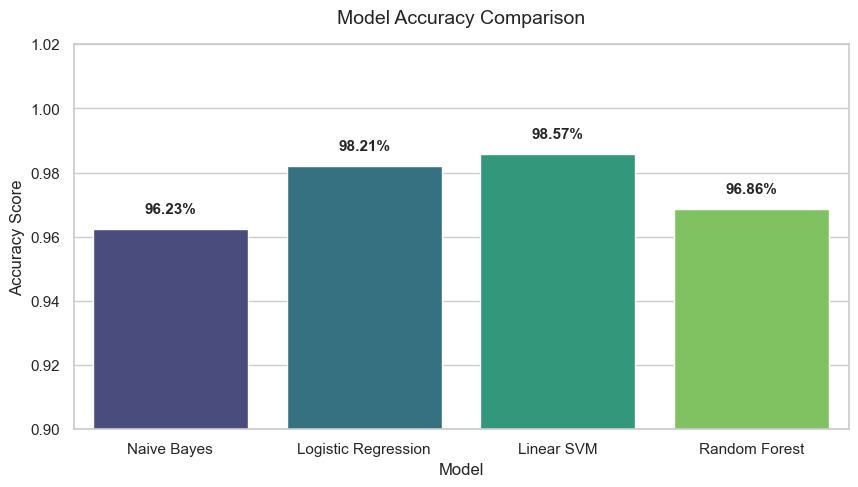

In [7]:
# Plot model accuracies
plt.figure(figsize=(10, 5))
model_names = list(model_accuracies.keys())
model_scores = list(model_accuracies.values())
sns.barplot(x=model_names, y=model_scores, palette="viridis", hue=model_names, legend=False)
plt.ylim(0.9, 1.02)
plt.title("Model Accuracy Comparison", fontsize=14, pad=15)
plt.ylabel("Accuracy Score", fontsize=12)
plt.xlabel("Model", fontsize=12)

for i, val in enumerate(model_scores):
    plt.text(i, val + 0.005, f"{val:.2%}", ha='center', fontweight='bold', fontsize=11)

plt.savefig("model_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

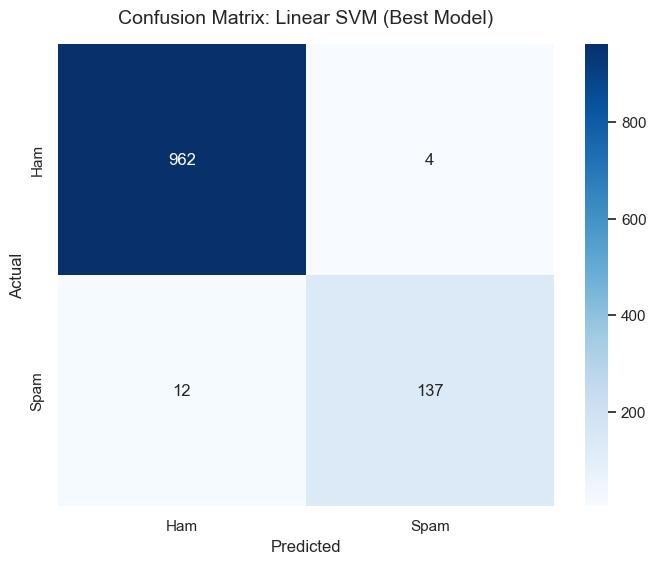

The best performing model on the test set is: Linear SVM with 98.57% accuracy!


In [8]:
# Find and evaluate the best model's confusion matrix
best_model_name = max(model_accuracies, key=model_accuracies.get)
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=['Ham', 'Spam'], 
            yticklabels=['Ham', 'Spam'])
plt.title(f"Confusion Matrix: {best_model_name} (Best Model)", fontsize=14, pad=15)
plt.ylabel("Actual", fontsize=12)
plt.xlabel("Predicted", fontsize=12)
plt.savefig("best_model_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"The best performing model on the test set is: {best_model_name} with {model_accuracies[best_model_name]:.2%} accuracy!")

## 🧪 Prediction Examples
Let's test our best model with some sample sentences (including potentially tricky phishing and spam emails).

In [9]:
example_messages = [
    "Congratulations! You've won a $1,000 gift card. Click here to claim.",
    "Hey, are we still meeting for lunch at 1 PM?",
    "URGENT: Your account has been compromised. Update your details immediately.",
    "Can you send me the report by EOD?"
]

# Preprocess, vectorize and predict
example_cleaned = [clean_text(msg) for msg in example_messages]
example_features = vectorizer.transform(example_cleaned)
predictions = best_model.predict(example_features)

print("Prediction Examples using the best model:")
for msg, pred in zip(example_messages, predictions):
    label = "Spam" if pred == 1 else "Ham (Not Spam)"
    print(f"- '{msg}' \n  → Prediction: {label}\n")

Prediction Examples using the best model:
- 'Congratulations! You've won a $1,000 gift card. Click here to claim.' 
  → Prediction: Spam

- 'Hey, are we still meeting for lunch at 1 PM?' 
  → Prediction: Ham (Not Spam)

- 'URGENT: Your account has been compromised. Update your details immediately.' 
  → Prediction: Spam

- 'Can you send me the report by EOD?' 
  → Prediction: Ham (Not Spam)

